# Elife Paper 
When using these notebooks for the first time, make sure the `load` parameter is False and `save` parameter is True. This will simulate and save the class including its data locally. While running it next time, and all consecutive times, make sure 'load' parameter is True. This will load the saved class locally saving essential runtime. 
## Figure 2: Landscape Generation
- B Syrinx reward landscapes
- C Artificial reward landscapes 
- B & A Spectrograms of 4 syllables


### Reward landscapes (A,B,C)

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import pickle
import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.plotting_functions import *
from dual_pathway_model.model import NN, Environment, params_base

Plotting colors safely loaded
Base parameters loaded from params.yaml


### 2 B: Syrinx Landscapes

In [2]:
# # load parameters and update with any changes
parameters = update_params(params_base, 
                               **{
                                   "params.LANDSCAPE": 1,
                                    "params.DAYS": 2,
                               }
                               )
# running conditions
TRIALS = parameters['params']['TRIALS'] 
DAYS = parameters['params']['DAYS'] 
N_SYLL = parameters['params']['N_SYLL']
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 40               
print(f'Random seed is {RANDOM_SEED}')

Random seed is 40


In [3]:
# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_2b" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = True # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_2b = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_2b = Environment(RANDOM_SEED, parameters, NN)
        obj_2b.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_2b = Environment(RANDOM_SEED, parameters, NN)
    obj_2b.run(parameters)



Model 'model_2b' not found. Running simulation...


100%|██████████| 2/2 [00:01<00:00,  1.45it/s]


Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape


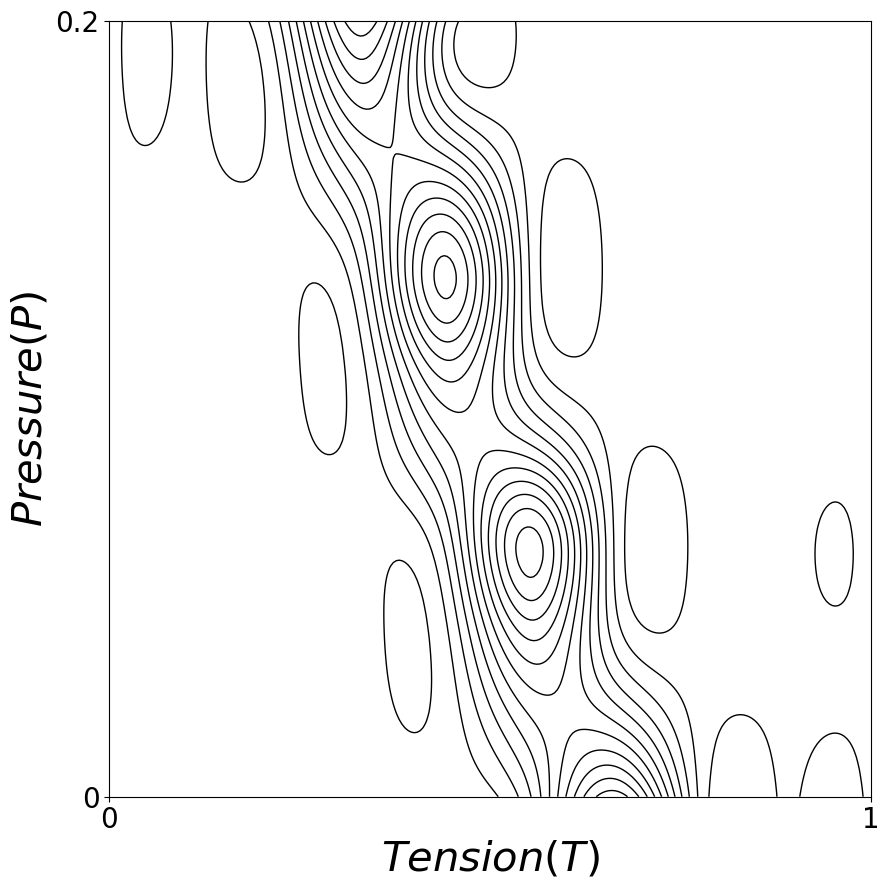

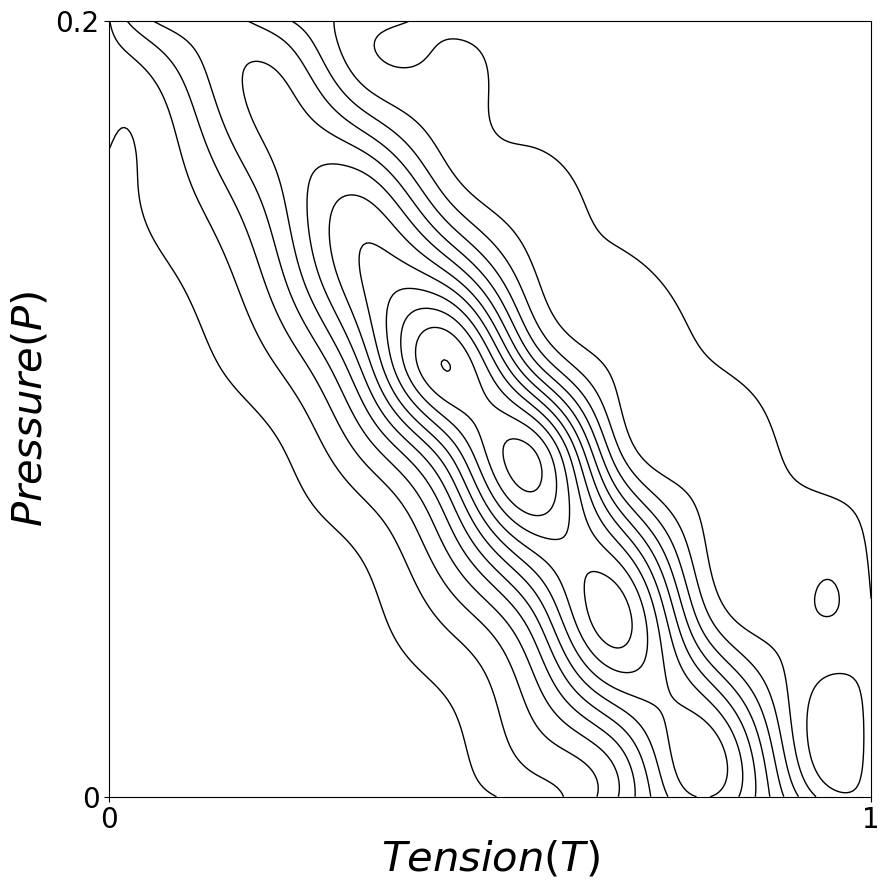

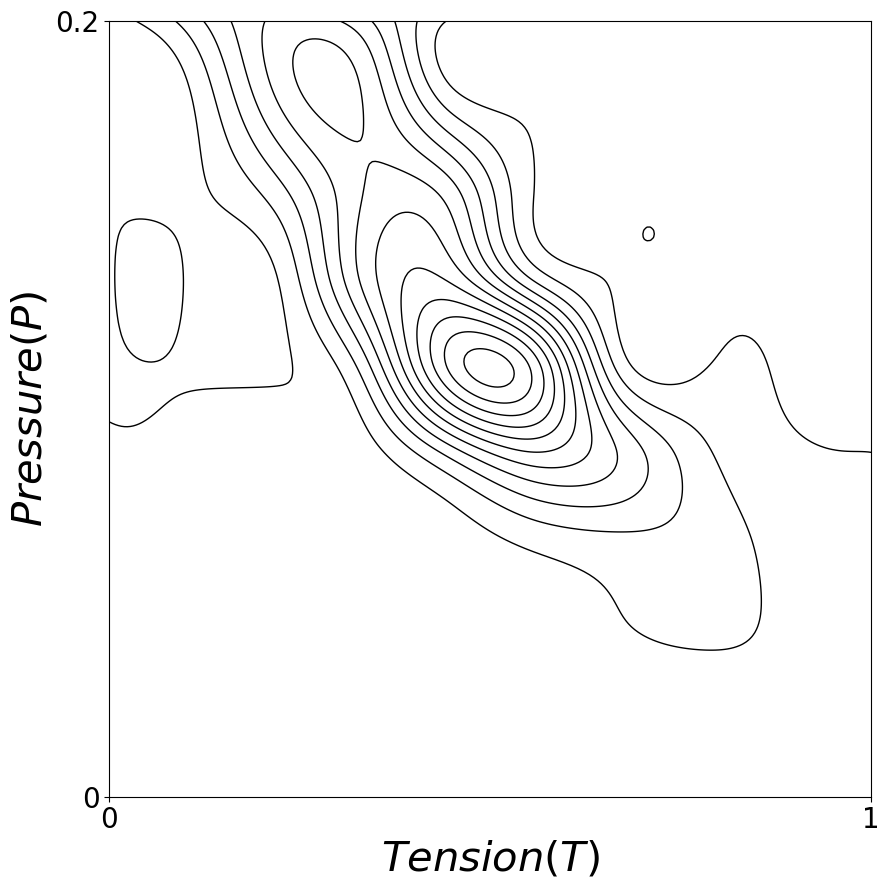

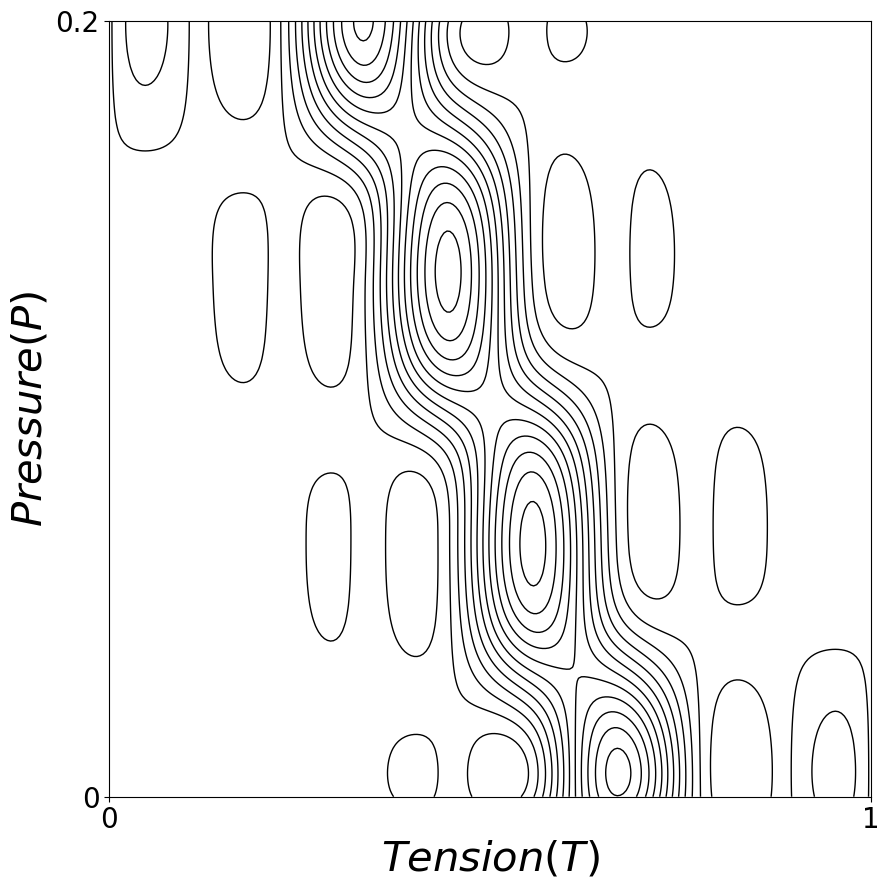

In [4]:
for syll in range(N_SYLL):
    plot_lansdcape_only(obj_2b, syll, contour_levels=12, contour_alpha=1)


### C: Artificial Landscapes

In [5]:
# # load parameters and update with any changes
parameters = update_params(params_base, 
                               **{
                                   "params.LANDSCAPE": 0,
                                    "params.DAYS": 2,
                               }
                               )
# running conditions
TRIALS = parameters['params']['TRIALS'] 
DAYS = parameters['params']['DAYS'] 
N_SYLL = parameters['params']['N_SYLL']
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 40               
print(f'Random seed is {RANDOM_SEED}')

Random seed is 40


In [6]:
# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_2c" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_2c = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_2c = Environment(RANDOM_SEED, parameters, NN)
        obj_2c.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_2c = Environment(RANDOM_SEED, parameters, NN)
    obj_2c.run(parameters)



Model 'model_2c' not found. Running simulation...


100%|██████████| 2/2 [00:01<00:00,  1.24it/s]


Plotting artificial landscape
Plotting artificial landscape
Plotting artificial landscape
Plotting artificial landscape


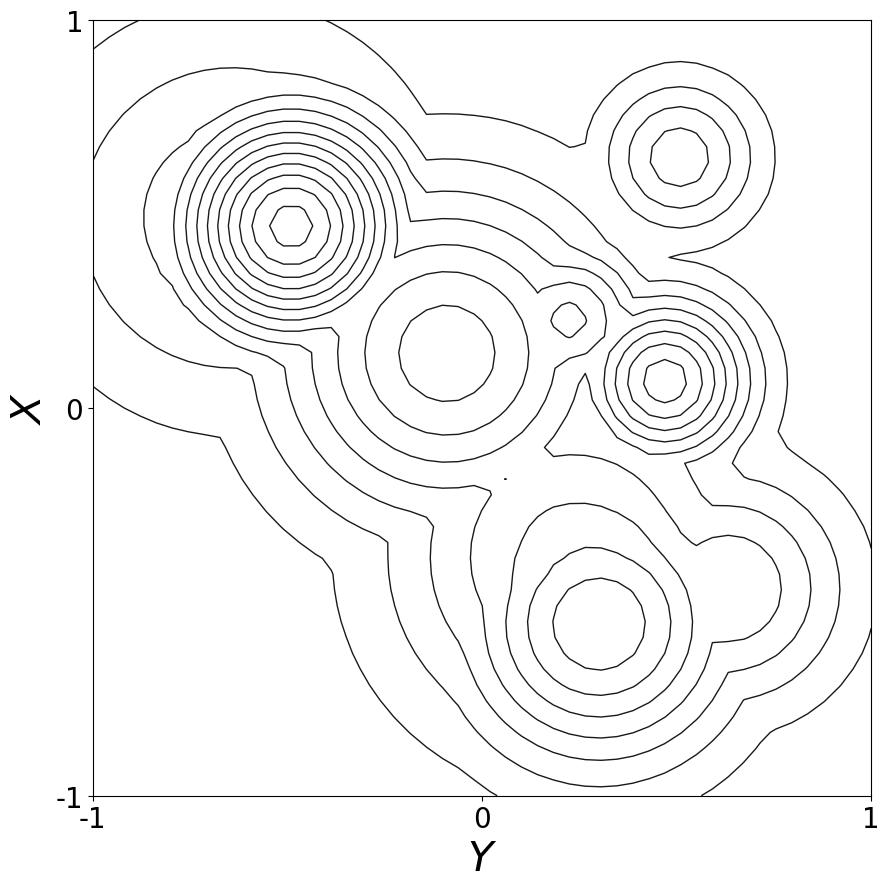

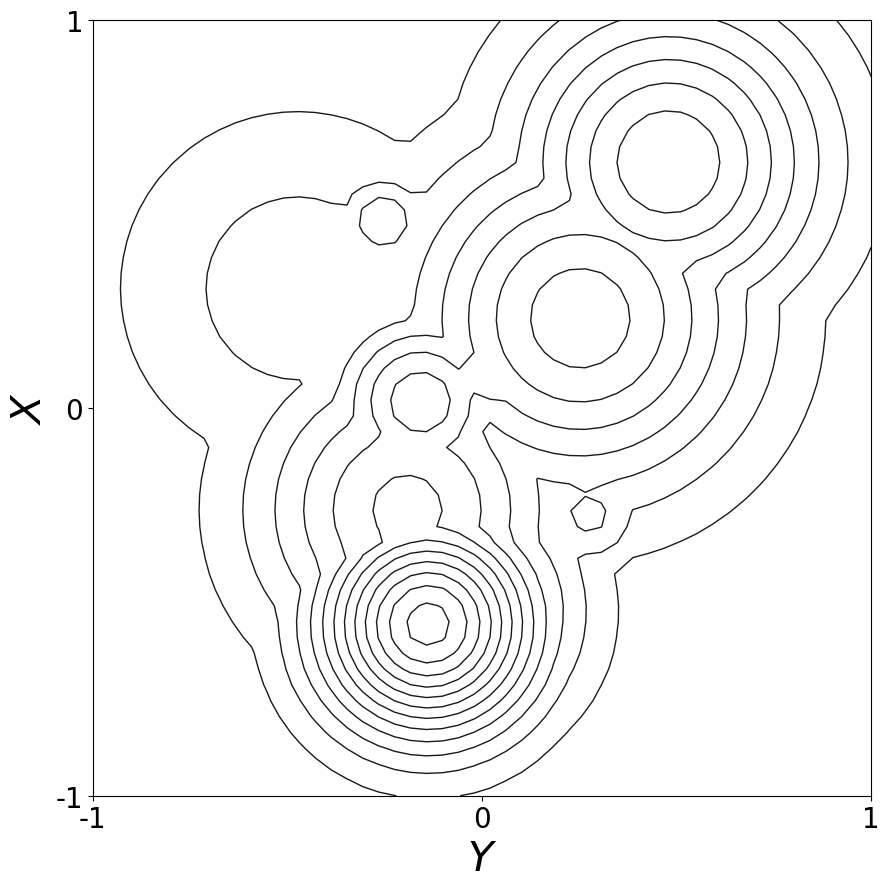

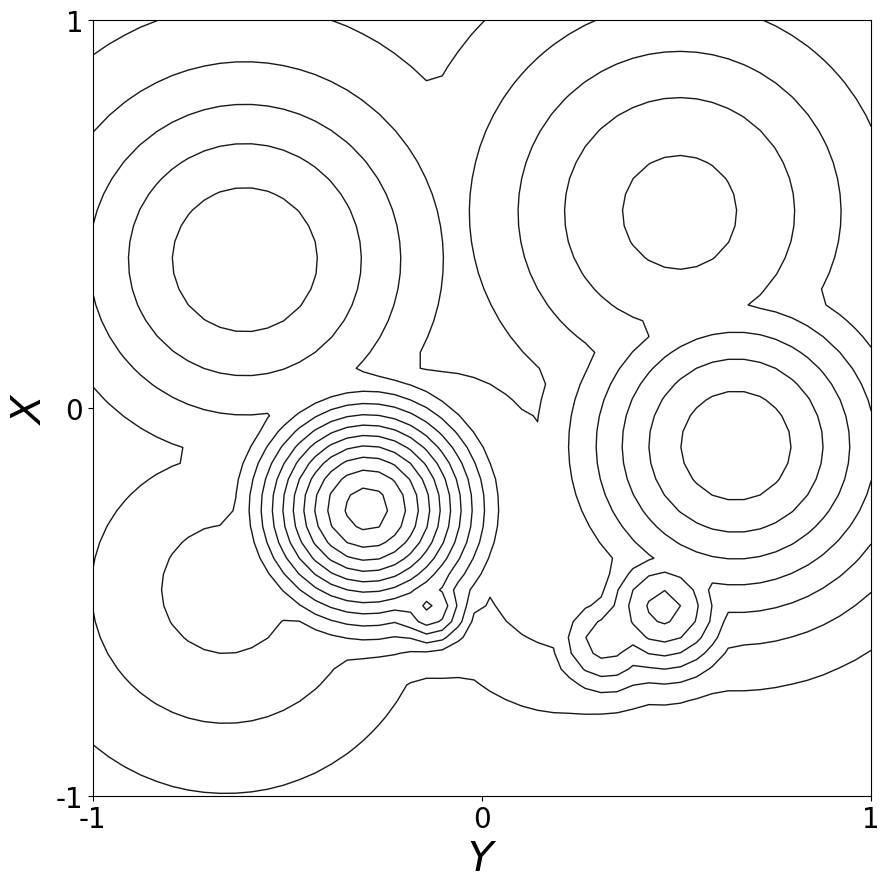

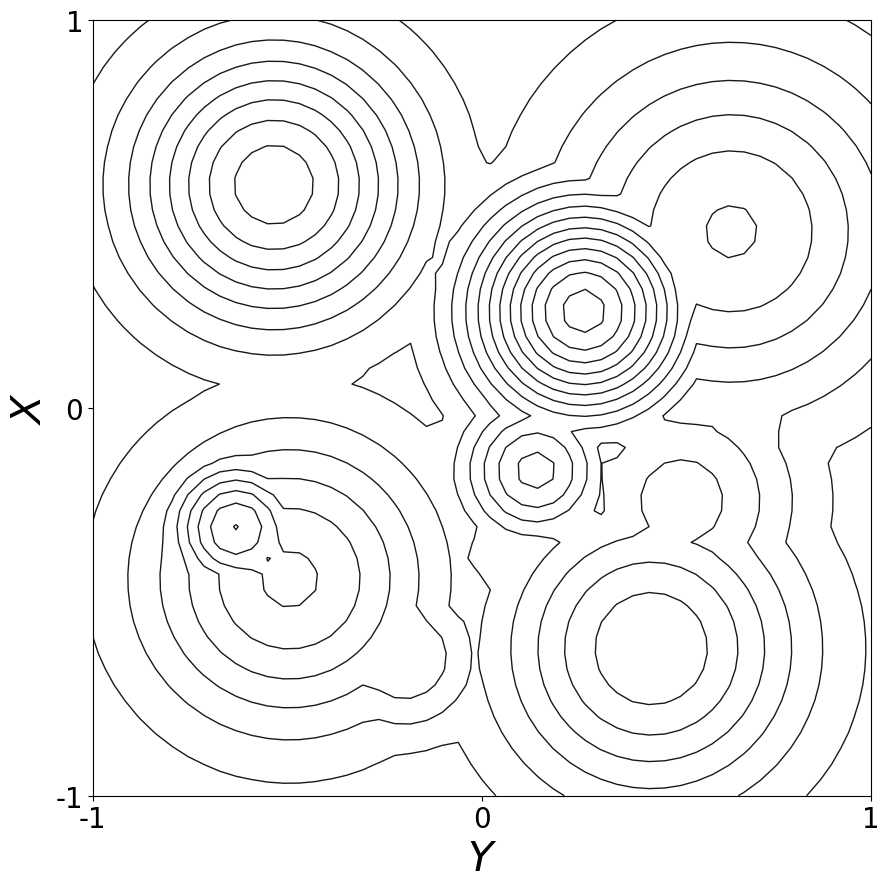

In [7]:

for syll in range(N_SYLL):
    plot_lansdcape_only(obj_2c, syll=syll, contour_levels=12, contour_alpha=1)

    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_2d_syll_{syll}.svg"), dpi=600, bbox_inches="tight")

### A & B Spectrograms
Plots 4 spectrograms for 4 syllables

In [8]:
np.random.seed(100)
# Parameters
gamma = 12000 

duration = 0.050 #s
dt = 1/44100 #s  #* 0.1 #1.e-4

Amp = 10

# Trachea parameters
r=-0.9
v=350*100
L=1.9
tau_0=2*L/v # Propagation time along trachea
tau_n=int(tau_0/dt)
# ks = np.linspace(0.16,0.52, 10)
# ps = np.linspace(1852,2084, 10)

# Track position and velocity 
nt = int(duration/dt)
X = np.zeros(nt)          # Labial position
Y = np.zeros(nt)          # Velocity

def sigmoid(x):
      return 1 / (1 + np.exp(-x))

def syrinxODE(t, y):
    ''' ODEs used in Amador paper'''
    
    y0, y1 = y
    dydt = [y1,
         -Pressure(t)*(gamma**2) - Tension(t)*(gamma**2)*y0 - (gamma**2)*(y0**3) - gamma*(y0**2)*y1 + (gamma**2)*(y0**2) - gamma*y0*y1
           ]
    return dydt

# RC4
# syllable 1
syllable_array = [1,2,3,4]
P_t_list = []  # <— add before the syllable loop




for syllable in syllable_array:
    if syllable == 1:
        def Tension(t):
            """ Generalised exponential waveform """
            return   .3 - .2*np.exp(-200*t) -.00001 * np.exp(200*t) 

        
        def Pressure(t):
            """ Constant """
            return 0.04*np.sin((duration/2 + t)*np.pi*10) + 0.05
    # RC5 - test
    elif syllable == 2:
        # syllable 2
        def Tension(t):
            """ Generalised exponential waveform """
            Tc = 1#2/3
            return   .3 - .2*np.exp(-Tc*3*100*t) -.00001 * np.exp(Tc*3*100*t) 

        def Pressure(t):
            """ Constant """
            tp = 0.2
            return tp*np.sin((duration/2 + t)*np.pi*10) + 0.05
    elif syllable == 3:
        # syllable 3
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            scale = 1
            if isinstance(t, float):
                if t <= duration*scale/2: 
                    return 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
                elif t <= duration*scale: 
                    return 10*np.sin((t-duration*scale/2)*np.pi*15/scale) + 0.6 # old amp 0.2
                else: 
                    return 0.0 + 0*t
            elif isinstance(t, np.ndarray):
                Tension1 = 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
                Tension2 = 10*np.sin(t*np.pi*15/scale) + 0.6 # old amp 0.2
                Tension3 = 0.0 + 0*t
                return np.concatenate((Tension1[:int(np.ceil(t.size*scale/2))], Tension2[:int(t.size*scale-t.size*scale/2)], Tension3[:int(t.size-t.size*scale)]))        
        
        def Pressure(t):
            """ Pressure = 0.02 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 2 # old amp 0.16
    elif syllable == 4:
        # syllable 4
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            scale = 0.4
            if isinstance(t, float):
                if t <= duration*scale: 
                    return 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
                else: 
                    return t*0 + 0.6 # old amp 0.2
            elif isinstance(t, np.ndarray):
                Tension1 = 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
                Tension2 = t* 0 + 0.6 # old amp 0.2
                return np.concatenate((Tension1[:int(np.ceil(t.size*scale))], Tension2[:int(t.size-t.size*scale)]))
            
        def Pressure(t):
            """ Pressure = 0.02 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.01
            
    elif syllable == 5:
        # syllable 5
        def Tension(t):
            """ Tension = 0.2 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.2
            
        def Pressure(t):
            """ Pressure = 0.1 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.1
    elif syllable == 6:
        # syllable 6
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            if isinstance(t, float):
                if t <= duration/2: return 0.1*np.sin(t*np.pi*40) + 0.6
                else: return 0.2*np.sin((t-duration/2)*np.pi*15) + 0.6
            elif isinstance(t, np.ndarray):
                Tension1 = 0.1*np.sin(t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(t*np.pi*15) + 0.6
                return np.concatenate((Tension1[:int(np.ceil(t.size/2))], Tension2[:int(t.size-t.size/2)]))
            
        def Pressure(t):
            """ Pressure = 0.01*np.sin(sin_t*np.pi*2*100) + 0.02 """
            return 0.01*np.sin(t*np.pi*2*100) + 0.02
        

    solution = solve_ivp(syrinxODE, [0, duration], [1, 1], method = "RK45", t_eval = np.linspace(0,duration,nt), rtol = 1e-8, atol = 1e-8)
    # Extract labial position (X) and velocity (Y)
    X = solution['y'][0]
    Y = solution['y'][1]
    # Transform into song
    time_x = np.linspace(0, duration, nt)
    song = Amp * Pressure(time_x) * Y
    ## Trachea from Darshan, et. al. https://doi.org/10.1038/ncomms15415

    # Input to trachea = output of syrinx
    y0 = song.T

    # To generate pressure output from trachea
    P_i=np.zeros((len(y0)))

    # See Fig 1 in Amador paper. Round-about way to implement that.
    Buffer = queue.Queue()
    for i in np.arange(tau_n):
        Buffer.put(np.random.random())

    for i in np.arange(len(y0)):
        P_i[i] = y0[i] - r*Buffer.get();      
        # update_buffer
        Buffer.put(P_i[i])

    # P_tr from P_in (ref Amador paper)
    BufferB=np.zeros((tau_n))
    P_tmp= np.concatenate((BufferB, P_i))
    P_t=(1-r)*P_tmp[:-tau_n]
    # ... inside your syllable loop, after computing P_t ...
    P_t_list.append(P_t.copy())
    time_x = np.linspace(0, duration, nt)




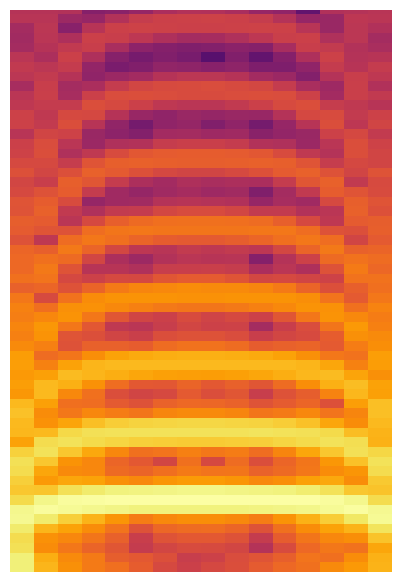

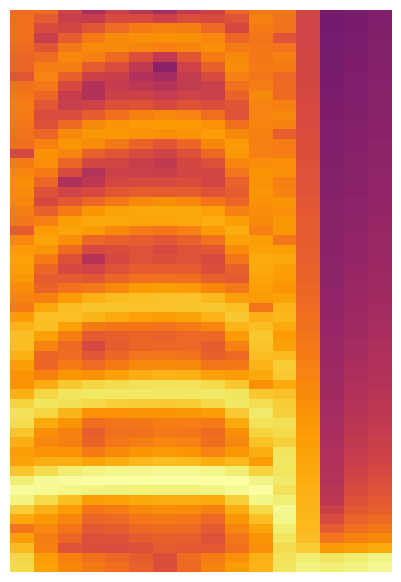

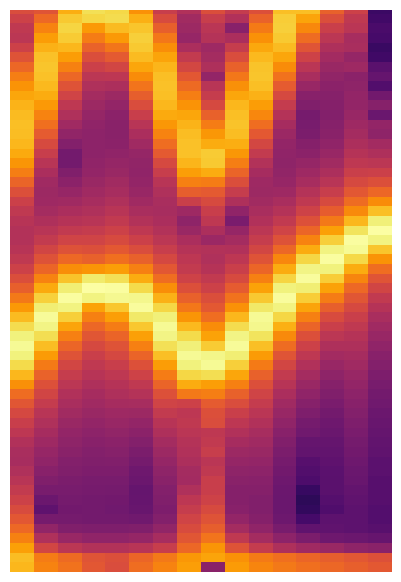

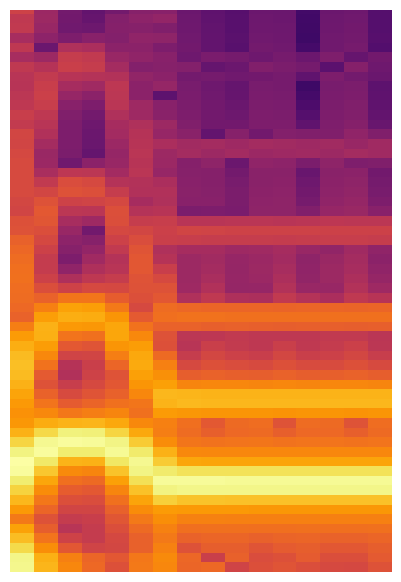

In [9]:
for i in range(4):
    P_t = P_t_list[i]
    figure, ax = plt.subplots(1)

    (spectrumP, freqsP, t, im) = plt.specgram(P_t, Fs=1/dt, NFFT=256, noverlap=128, xextent=[0,.05], cmap='inferno')
    im


    # ax.set_ylabel('Frequency (kHz)', fontsize=30)
    # ax.set_xlabel('Time (s)', fontsize=30)
    # ax.set_title(f'Syllable:{syllable}', fontsize=30)

    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.set_ylim(0,10000)
    ax.set_xlim(0,.05)
    # ax.set_xticklabels([])
    # ax.set_yticks([0, 10000])
    # ax.set_yticklabels([0, 10])
    # ax.set_yticklabels([])
    # ax.tick_params(labelsize=15)
    ax.axis('off')
    figure.tight_layout()

    figure.set_size_inches(4, 6, forward=True)


    plt.plot()
    # plt.show()
    
    # os.makedirs("Plots", exist_ok=True)
    # plt.savefig(os.path.join("Plots", f"landscape_2b_spec_{i}.svg"), dpi=600, bbox_inches="tight")